<a href="https://colab.research.google.com/github/dataprogpy/code-samples/blob/main/starter_files/06_modeling_workflow_with_sklearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modeling with scikit-learn

In [1]:
# data tools
import polars as pl
import pandas as pd
import polars.selectors as cs
import numpy as np
import random

# graphing tools
import altair as alt
import matplotlib.pyplot as plt

# sklearn config
from sklearn import set_config

# data
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# model
from sklearn import tree

# inspection and evaluation
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.metrics import ConfusionMatrixDisplay


In [2]:
alt.data_transformers.disable_max_rows()
set_config(transform_output='polars')
random.seed(42)  # For reproducibility.

## Loading Data

In [3]:
iris = load_iris(as_frame=True)
print(iris.frame.columns)
print(iris.target_names)
iris.frame.head()

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')
['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## Finding "Good" Features

In [4]:
label_mapper = lambda label: iris.target_names[label]
df = (
    pl.from_pandas(iris.frame)
    .select(
        pl.col("sepal length (cm)").alias("sepalLength"),
        pl.col("sepal width (cm)").alias("sepalWidth"),
        pl.col("petal length (cm)").alias("petalLength"),
        pl.col("petal width (cm)").alias("petalWidth"),
        pl.col("target").map_elements(
            label_mapper,
            return_dtype=pl.String
            ).alias("species"),
    )
)

df.head()

sepalLength,sepalWidth,petalLength,petalWidth,species
f64,f64,f64,f64,str
5.1,3.5,1.4,0.2,"""setosa"""
4.9,3.0,1.4,0.2,"""setosa"""
4.7,3.2,1.3,0.2,"""setosa"""
4.6,3.1,1.5,0.2,"""setosa"""
5.0,3.6,1.4,0.2,"""setosa"""


### Feature Distribution

In [5]:
alt.Chart(df).transform_fold(
    [
        "petalWidth",
        "petalLength",
        "sepalWidth",
        "sepalLength",
    ],
    as_=["Measurement_type", "value"],
).transform_density(
    density="value",
    bandwidth=0.3,
    groupby=["Measurement_type"],
    extent=[0, 8],
).mark_area().encode(
    alt.X("value:Q"),
    alt.Y("density:Q"),
    alt.Row("Measurement_type:N"),
).properties(
    width=300, height=50
)

alt.Chart(...)

### Relating Features and Target

**Do features contain enough information to predict target label?**

In [6]:
alt.Chart(df).mark_point(opacity=0.5).encode(
    alt.X(alt.repeat("column"), type='quantitative'),
    alt.Y(alt.repeat("row"), type='quantitative'),
    color='species:N'
).properties(
    width=200,
    height=200
).repeat(
    row=['petalLength', 'petalWidth'],
    column=['sepalLength', 'sepalWidth']
)

alt.RepeatChart(...)

In [7]:
alt.Chart(df, width=500).transform_window(
    index='count()'
).transform_fold(
    ['petalLength', 'petalWidth', 'sepalLength', 'sepalWidth']
).mark_line().encode(
    x='key:N',
    y='value:Q',
    color='species:N',
    detail='index:N',
    opacity=alt.value(0.5)
)

alt.Chart(...)

In [8]:
chart1 = alt.Chart(df).mark_point().encode(
    x=alt.X('petalWidth').title("Petal Width"),
    y=alt.Y('petalLength').title("Petal Length"),
    color=alt.Color('species').title("Species")
).properties(
    height=300,
    width=300
)

chart2 = alt.Chart(df).mark_bar().encode(
    x=alt.X('count()'),
    y=alt.Y('petalWidth:Q').bin(maxbins=30).title("Petal Width (binned)"),
    color=alt.Color('species').title("Species")
).properties(
    height=300,
    width=100
)

chart1 | chart2

alt.HConcatChart(...)

## Modeling to Predict Iris Species

## Modeling Workflow

1. Load & Prepare Data
1. Split the data
1. Initialize Model
1. Train the Model
1. Predict Labels
1. Evaluate Model Performance

### Load and prepare the data

In [9]:
# Load the dataset from scikit-learn
iris_data = load_iris()

# Create a Polars DataFrame
# The data is in '.data' and column names in '.feature_names'
df = pl.DataFrame(
    data=iris_data.data,
    schema=iris_data.feature_names
).with_columns(
    # Add the target variable, which is in '.target'
    pl.Series(name="target", values=iris_data.target),
)

df.head()

sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
f64,f64,f64,f64,i64
5.1,3.5,1.4,0.2,0
4.9,3.0,1.4,0.2,0
4.7,3.2,1.3,0.2,0
4.6,3.1,1.5,0.2,0
5.0,3.6,1.4,0.2,0


In [10]:
# Define our features (X) and target (y)
X = df.select(pl.exclude("target"))
y = df.select("target")

# Display the first 5 rows of the feature DataFrame
print("Features (X):")
X.head()

Features (X):


sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
f64,f64,f64,f64
5.1,3.5,1.4,0.2
4.9,3.0,1.4,0.2
4.7,3.2,1.3,0.2
4.6,3.1,1.5,0.2
5.0,3.6,1.4,0.2


In [11]:
# Display the first 5 rows of the target DataFrame
print("\nTarget (y):")
y.head()



Target (y):


target
i64
0
0
0
0
0


### Split the data into training and test sets

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Verify the dimensions of the resulting datasets
print(f"""
  Shape of X_train: {X_train.shape}.
  Shape of X_test: {X_test.shape}.
  """)



  Shape of X_train: (105, 4).
  Shape of X_test: (45, 4).
  


### Initialize the model

In [13]:
model = tree.DecisionTreeClassifier(max_depth=3, random_state=42)
print(model)


DecisionTreeClassifier(max_depth=3, random_state=42)


### Train the model

In [14]:
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

### Generate Predictions

In [15]:
# Generate predictions for the test set
predictions = model.predict(X_test)

# Display the first 10 predictions
predictions[:10]


array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1])

### Evaluate model performance

In [16]:
# Calculate the accuracy of the model
print(f"Mean Accuracy Score: {model.score(X_test, y_test):.4f}")

Mean Accuracy Score: 1.0000


#### Understanding the decision tree structure

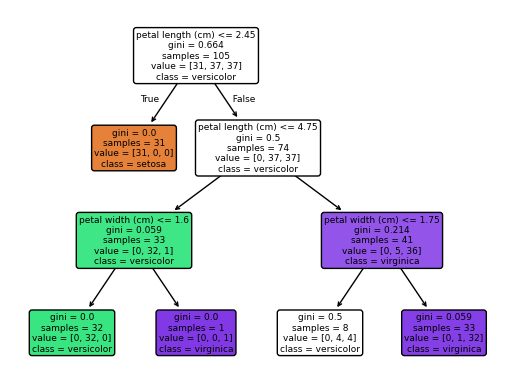

In [17]:
# Create the plot
tree.plot_tree(
    model,
    feature_names=X.columns,
    class_names=iris_data.target_names,
    filled=True,
    rounded=True
)

# Display the plot
plt.show()

#### Model evaluation using confusion matrix

Confusion matrix, without normalization
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Normalized confusion matrix
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]


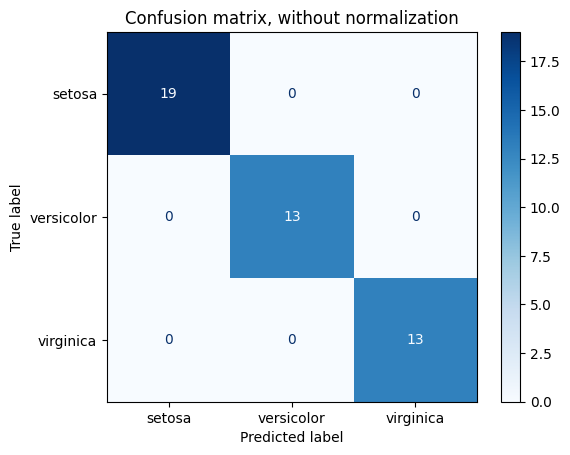

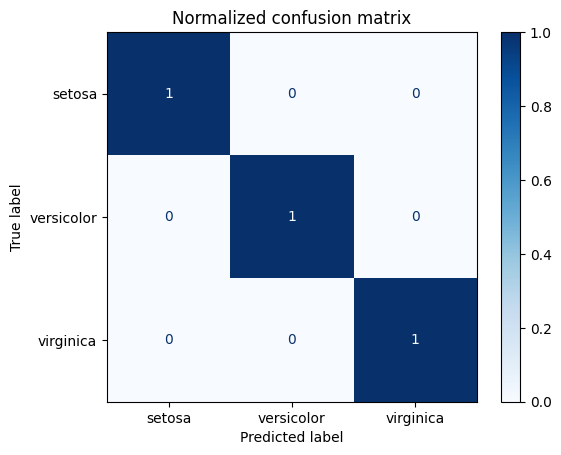

In [18]:
class_names = iris.target_names
# Plot non-normalized confusion matrix
titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        model,
        X_test,
        y_test,
        display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)

plt.show()

#### Evaluating decision surface

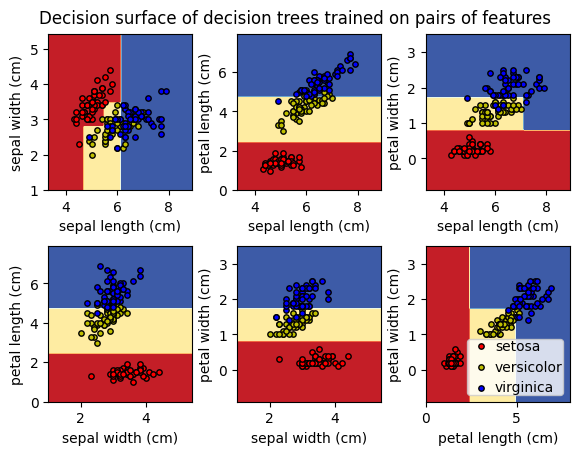

In [19]:
iris = load_iris()

# Parameters
n_classes = 3
plot_colors = "ryb"
plot_step = 0.02


for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3], [1, 2], [1, 3], [2, 3]]):
    # We only take the two corresponding features
    X = iris.data[:, pair]
    y = iris.target
    class_names = iris.target_names

    # Train
    clf = tree.DecisionTreeClassifier(max_depth=3, random_state=42).fit(X, y)

    # Plot the decision boundary
    ax = plt.subplot(2, 3, pairidx + 1)
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
    DecisionBoundaryDisplay.from_estimator(
        clf,
        X,
        cmap=plt.cm.RdYlBu,
        response_method="predict",
        ax=ax,
        xlabel=iris.feature_names[pair[0]],
        ylabel=iris.feature_names[pair[1]],
    )

    # Plot the training points
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.asarray(y == i).nonzero()
        plt.scatter(
            X[idx, 0],
            X[idx, 1],
            c=color,
            label=iris.target_names[i],
            edgecolor="black",
            s=15,
        )

plt.suptitle("Decision surface of decision trees trained on pairs of features")
plt.legend(loc="lower right", borderpad=0, handletextpad=0)
_ = plt.axis("tight")

## scikit-learn Estimator API

**References**:
- [Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html)
- [Decision trees - scikit-learn](https://scikit-learn.org/stable/modules/tree.html)
- [scikit-learn datasets - Iris](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_iris.html)
- [Understanding the decision tree structure](https://scikit-learn.org/stable/auto_examples/tree/plot_unveil_tree_structure.html)
- [Visualizing confusion matrix](https://scikit-learn.org/stable/auto_examples/model_selection/plot_confusion_matrix.html)
- [Visualizing decision surface of a decision tree](https://scikit-learn.org/stable/auto_examples/tree/plot_iris_dtc.html)
- [Precision-Recall](https://scikit-learn.org/stable/auto_examples/model_selection/plot_precision_recall.html)